# 55B and 55C fitted curves and static renderings

Load the saved outputs from `cf.ipynb`, overlay both stitched observations and heterogeneous-line fits, and make one non-interactive 3D rendering for each sample. The 55C render uses the original box-to-mask ratios; the 55B ratios are adjusted so both rendered boxes have exactly the same visual dimensions.

In [1]:
from pathlib import Path
import sys

# Ensure cf_tools resolves the scattering implementation in smpl/, as in cf.ipynb.
SMPL_DIR = Path.cwd().parent.resolve()
sys.path.insert(0, str(SMPL_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Preload the smpl implementation before the renderer adds the project root.
import rw_line_scattering as rls
import cf_tools as cf

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pv.OFF_SCREEN = True

OUTPUT_DIR = Path("output")
SAMPLE_TAGS = ("55B_R0", "55C_R0")
COLORS = {"55B_R0": "#0072B2", "55C_R0": "#D55E00"}

## Load the saved observations, fit curves, and parameters

In [2]:
def load_named_values(path):
    table = np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    return {str(row["name"]): float(row["value"]) for row in np.atleast_1d(table)}


observations = {
    tag: np.genfromtxt(
        OUTPUT_DIR / f"{tag}_stitched_observation.csv",
        delimiter=",",
        names=True,
    )
    for tag in SAMPLE_TAGS
}
fit_curves = {
    tag: np.genfromtxt(
        OUTPUT_DIR / f"{tag}_first_fit_curve.csv",
        delimiter=",",
        names=True,
    )
    for tag in SAMPLE_TAGS
}
fit_parameters = {
    tag: load_named_values(OUTPUT_DIR / f"{tag}_first_fit_parameters.csv")
    for tag in SAMPLE_TAGS
}

for tag in SAMPLE_TAGS:
    print(
        f"[status] {tag}: observation points={observations[tag].size}, "
        f"fit points={fit_curves[tag].size}, "
        f"mean_k={fit_parameters[tag]['mean_k']:.6g}, "
        f"k_H/k={fit_parameters[tag]['k_H_over_k']:.6g}"
    )

[status] 55B_R0: observation points=159, fit points=149, mean_k=0.0332441, k_H/k=0.0794543
[status] 55C_R0: observation points=159, fit points=149, mean_k=0.0543869, k_H/k=0.0568938


## Stitched curves and model fits on one plot

[status] saved output\55B_55C_stitched_and_model_fits.png


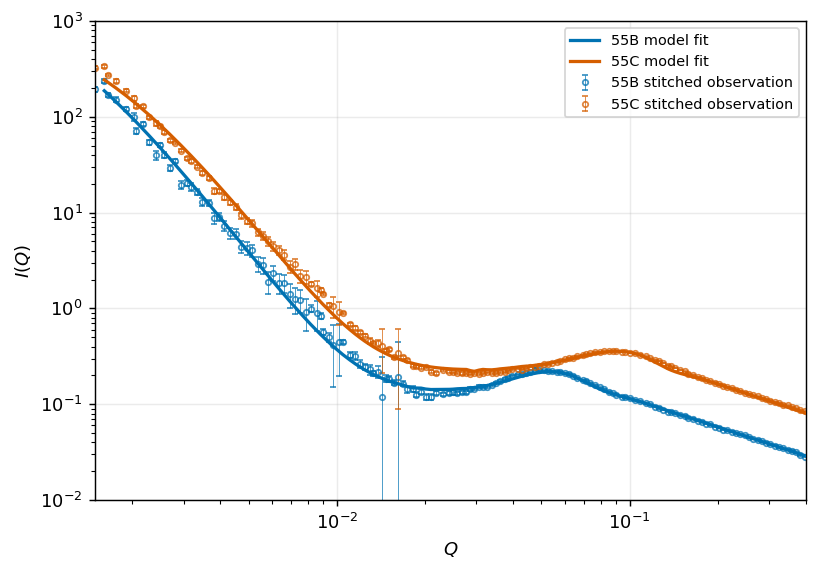

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 4.5))

for tag in SAMPLE_TAGS:
    label = tag.split("_")[0]
    obs = observations[tag]
    fit = fit_curves[tag]
    positive = np.isfinite(obs["I"]) & (obs["I"] > 0.0)
    ax.errorbar(
        obs["Q"][positive],
        obs["I"][positive],
        yerr=obs["err"][positive],
        fmt="o",
        ms=3.0,
        lw=0.5,
        capsize=1.5,
        color=COLORS[tag],
        markerfacecolor="none",
        alpha=0.75,
        label=f"{label} stitched observation",
    )
    ax.plot(
        fit["Q"],
        fit["I_fit"],
        color=COLORS[tag],
        lw=1.8,
        label=f"{label} model fit",
        zorder=10,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.5e-3, 4.0e-1)
ax.set_ylim(1e-2, 1e3)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()

COMPARISON_PLOT = OUTPUT_DIR / "55B_55C_stitched_and_model_fits.png"
fig.savefig(COMPARISON_PLOT)
print(f"[status] saved {COMPARISON_PLOT}")

## Static 3D renderings with a common box size

The renderer uses the normalized visual mask length $L_H=1/k_H$, where `visual_k_H = RENDER_K_LINE * k_H_over_k`. Since its input ratio is `box_size / L_H`, maintaining the 55C box size requires

$$R_x = R_{55C}\,\frac{L_{H,55C}}{L_{H,x}} = R_{55C}\,\frac{k_{H,x}}{k_{H,55C}}.$$

This is applied to both the lateral ratio (15.0 for 55C) and thickness ratio (0.8 for 55C). All other render settings match `cf.ipynb`. Rendering is off-screen and only static PNG files are produced.

In [4]:
RENDER_RANDOM_SEED = 114514
RENDER_K_LINE = 10.0
RENDER_NUM_LINE_MODES = 128
RENDER_NX = 150
RENDER_NY = 150
RENDER_NZ = 8
RENDER_55C_LATERAL_SIZE_OVER_MASK_LENGTH = 15.0
RENDER_55C_THICKNESS_OVER_MASK_LENGTH = 0.8
RENDER_LINE_TUBE_RADIUS_FRACTION = 0.002
RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K = 10.0
RENDER_SHOW_MASK_BOUNDARY = False
RENDER_SHOW_BOX_BOUNDARY = True
RENDER_SHOW_REJECTED_LINES = False
RENDER_WINDOW_SIZE = (800, 800)
RENDER_WINDOW_FILL_FRACTION = 0.95
RENDER_INITIAL_VIEW = "normal"
RENDER_SCREENSHOT_SCALE = 3

REFERENCE_TAG = "55C_R0"
visual_k_H = {
    tag: RENDER_K_LINE * fit_parameters[tag]["k_H_over_k"]
    for tag in SAMPLE_TAGS
}
visual_mask_length = {tag: 1.0 / visual_k_H[tag] for tag in SAMPLE_TAGS}
ratio_scale = {
    tag: visual_k_H[tag] / visual_k_H[REFERENCE_TAG]
    for tag in SAMPLE_TAGS
}
render_lateral_ratio = {
    tag: RENDER_55C_LATERAL_SIZE_OVER_MASK_LENGTH * ratio_scale[tag]
    for tag in SAMPLE_TAGS
}
render_thickness_ratio = {
    tag: RENDER_55C_THICKNESS_OVER_MASK_LENGTH * ratio_scale[tag]
    for tag in SAMPLE_TAGS
}

for tag in SAMPLE_TAGS:
    lateral_size = render_lateral_ratio[tag] * visual_mask_length[tag]
    thickness = render_thickness_ratio[tag] * visual_mask_length[tag]
    print(
        f"[render settings] {tag}: mask_length={visual_mask_length[tag]:.6g}, "
        f"lateral_ratio={render_lateral_ratio[tag]:.6g}, "
        f"thickness_ratio={render_thickness_ratio[tag]:.6g}, "
        f"box=({lateral_size:.6g}, {lateral_size:.6g}, {thickness:.6g})"
    )

[render settings] 55B_R0: mask_length=1.25859, lateral_ratio=20.9481, thickness_ratio=1.11723, box=(26.3649, 26.3649, 1.40613)
[render settings] 55C_R0: mask_length=1.75766, lateral_ratio=15, thickness_ratio=0.8, box=(26.3649, 26.3649, 1.40613)


In [5]:
render_results = {}

for tag in SAMPLE_TAGS:
    screenshot_path = OUTPUT_DIR / f"{tag}_fit_heterogeneous_common_box.png"
    params = fit_parameters[tag]
    preview = cf.render_fit_heterogeneous_preview(
        params,
        output_path=screenshot_path,
        visual_k_line=RENDER_K_LINE,
        line_k_distribution="max_entropy_radial",
        line_r_sigma_k=params["r_sigma_k"],
        line_k_distribution_params={"skewness": params["skewness"]},
        random_seed=RENDER_RANDOM_SEED,
        num_line_modes=RENDER_NUM_LINE_MODES,
        nx=RENDER_NX,
        ny=RENDER_NY,
        nz=RENDER_NZ,
        lateral_size_over_mask_length=render_lateral_ratio[tag],
        thickness_over_mask_length=render_thickness_ratio[tag],
        line_tube_radius_fraction=RENDER_LINE_TUBE_RADIUS_FRACTION,
        min_retained_line_length_over_k=RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K,
        show_mask_boundary=RENDER_SHOW_MASK_BOUNDARY,
        show_box_boundary=RENDER_SHOW_BOX_BOUNDARY,
        show_rejected_lines=RENDER_SHOW_REJECTED_LINES,
        window_size=RENDER_WINDOW_SIZE,
        window_fill_fraction=RENDER_WINDOW_FILL_FRACTION,
        initial_view=RENDER_INITIAL_VIEW,
        screenshot_scale=RENDER_SCREENSHOT_SCALE,
    )
    render_results[tag] = preview
    preview.plotter.close()
    print(
        f"[status] saved {screenshot_path}; "
        f"retained cells={preview.retained_cells}, retained points={preview.retained_points}, "
        f"box=({preview.lateral_size:.6g}, {preview.lateral_size:.6g}, {preview.thickness:.6g})"
    )

assert np.isclose(render_results["55B_R0"].lateral_size, render_results["55C_R0"].lateral_size)
assert np.isclose(render_results["55B_R0"].thickness, render_results["55C_R0"].thickness)
print("[status] verified: 55B and 55C render boxes have the same dimensions")

[status] saved output\55B_R0_fit_heterogeneous_common_box.png; retained cells=2351, retained points=79008, box=(26.3649, 26.3649, 1.40613)


[status] saved output\55C_R0_fit_heterogeneous_common_box.png; retained cells=3025, retained points=105110, box=(26.3649, 26.3649, 1.40613)
[status] verified: 55B and 55C render boxes have the same dimensions
